<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower

## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [2]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.4784603394194413


In [3]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.042196715924889903
95% confidence interval: (np.float64(-0.5450733877678522), np.float64(-0.010926612232152355))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.04299838008890299
Degrees of freedom: 17.02484516235282
95% confidence interval: (np.float64(-0.5461741394750395), np.float64(-0.00982586052496498))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


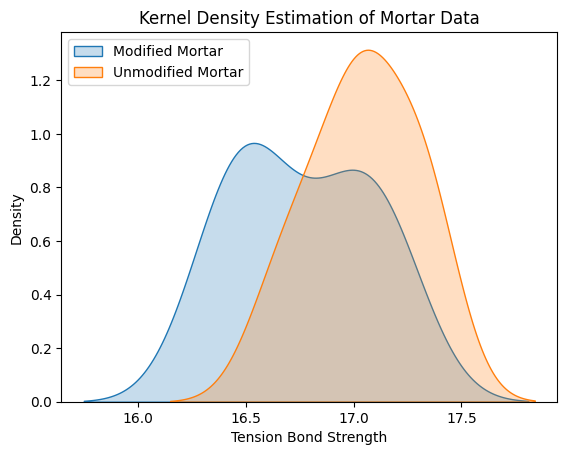

In [4]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

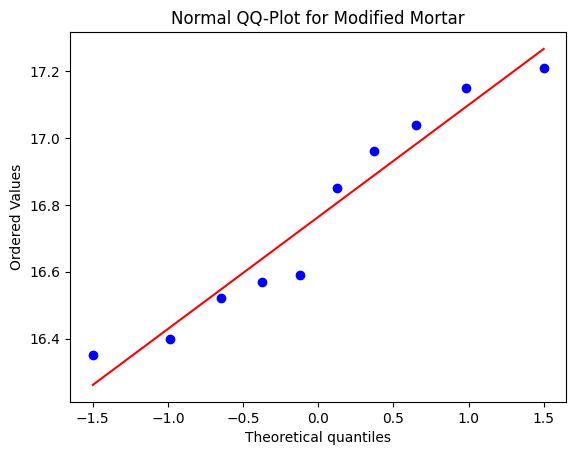

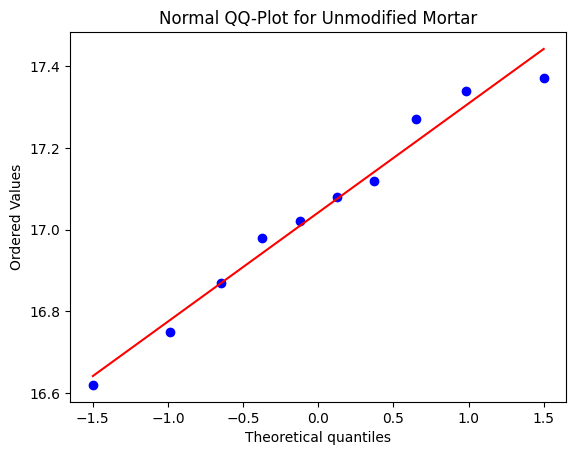

In [5]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [6]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332801846344, p-value=0.3456968630049325
Shapiro-Wilk Test for y2: Statistic=0.9626192871584892, p-value=0.8152773063551302


In [7]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.5436442278126237


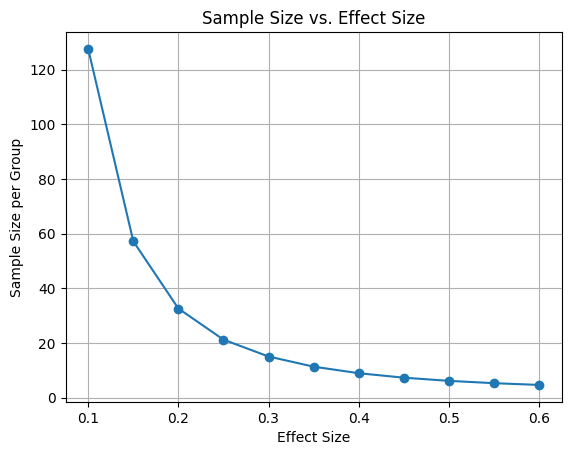

In [8]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [9]:
# Read the data from the URL
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

# Display the first few rows of the dataframe
df20.head()


,Days
0,108
1,124
2,124
3,106
4,115


**Solution:**

**Hypotheses.** We want to show that the mean shelf life is more than 120 days. The claim goes into $H_1$. The test is one-sided, because only the direction "more than 120" matters:

$$H_0:\ \mu = 120 \qquad H_1:\ \mu > 120$$

The variance is unknown and $n = 10$, so we use the one-sample $t$-test, $t_0 = \dfrac{\bar y - 120}{s/\sqrt{n}}$ with $df = 9$.

In [10]:
y20 = df20["Days"].to_numpy(dtype=float)
n = len(y20)
ybar, s = y20.mean(), y20.std(ddof=1)
se = s / np.sqrt(n)
mu0 = 120

# Test statistic and one-sided p-value for H1: mu > 120
t0 = (ybar - mu0) / se
p_one_sided = 1 - stats.t.cdf(t0, df=n - 1)
t_crit = stats.t.ppf(0.99, df=n - 1)          # alpha = 0.01, one-sided

print(f"n = {n}, mean = {ybar:.2f} days, s = {s:.3f}, se = {se:.3f}")
print(f"t0 = {t0:.3f}, df = {n - 1}")
print(f"one-sided p-value = {p_one_sided:.4f}")
print(f"critical value t_0.99({n - 1}) = {t_crit:.3f}")


n = 10, mean = 131.00 days, s = 19.545, se = 6.181
t0 = 1.780, df = 9
one-sided p-value = 0.0544
critical value t_0.99(9) = 2.821


**Conclusion.** $t_0 = 1.78 < t_{0.99}(9) = 2.82$, one-sided $P = 0.054 > 0.01$. We **do not reject $H_0$**: the data do not prove that the mean shelf life is above 120 days.
The sample mean (131 days) is above 120, but 10 bottles with $s = 19.5$ days are not enough for the strict 1 % level.

In [11]:
# 99% two-sided confidence interval on the mean
ci99 = stats.t.interval(0.99, df=n - 1, loc=ybar, scale=se)
# 99% one-sided lower confidence bound (this is the interval that matches the one-sided test)
lower99 = ybar - stats.t.ppf(0.99, df=n - 1) * se

print(f"99% two-sided CI for mu: ({ci99[0]:.2f}, {ci99[1]:.2f}) days")
print(f"99% lower confidence bound:  mu >= {lower99:.2f} days")

99% two-sided CI for mu: (110.91, 151.09) days
99% lower confidence bound:  mu >= 113.56 days


**Confidence interval.** The 99 % two-sided interval is $(110.9,\ 151.1)$ days. The 99 % lower bound is $\mu \ge 113.6$ days.
Both contain 120, so this is the same result as the test. The interval is 40 days wide: with 10 bottles we know the mean only roughly.

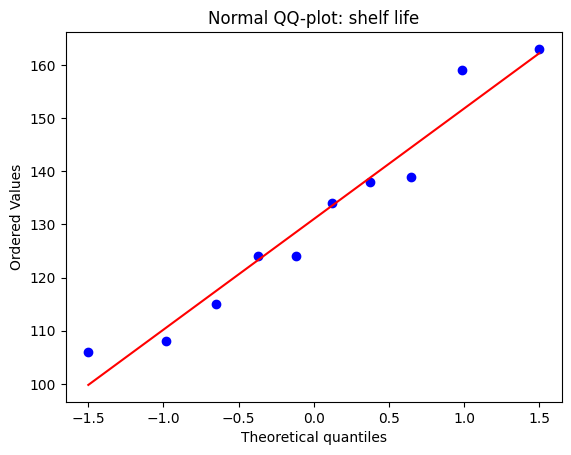

Shapiro-Wilk: W = 0.9365, p = 0.5152
sample skewness = 0.361


In [12]:
plt.figure()
stats.probplot(y20, dist="norm", plot=plt)
plt.title("Normal QQ-plot: shelf life")
plt.show()

sw = shapiro(y20)
print(f"Shapiro-Wilk: W = {sw.statistic:.4f}, p = {sw.pvalue:.4f}")
print(f"sample skewness = {stats.skew(y20):.3f}")

**Normality.** The QQ-plot is close to a straight line and the Shapiro-Wilk test does not reject normality ($W = 0.937$, $p = 0.52$).
Normality is a reasonable assumption. With $n = 10$ the test has little power, so this is only weak evidence.

**Effect of a violation.** The $t$-test is robust to mild non-normality, because the sample mean is close to normal even when the data are not (central limit theorem).
With $n = 10$, strong skewness or outliers could change the true $\alpha$ and the coverage of the confidence interval. In that case a nonparametric test (Wilcoxon signed-rank) would be safer.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [13]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


**Solution:**

**(a)** Two independent samples, $n_1 = n_2 = 8$, equal variances assumed, so we use the pooled two-sample $t$-test:

$$H_0:\ \mu_1 = \mu_2 \qquad H_1:\ \mu_1 \ne \mu_2, \qquad
t_0 = \frac{\bar y_1 - \bar y_2}{s_p\sqrt{1/n_1 + 1/n_2}},\quad s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2},\quad df = 14.$$

In [14]:
s1 = df21["Solution1"].to_numpy(dtype=float)
s2 = df21["Solution2"].to_numpy(dtype=float)
n1, n2 = len(s1), len(s2)

# (a) pooled two-sample t-test, alpha = 0.05
res = stats.ttest_ind(s1, s2, equal_var=True)
sp = np.sqrt(((n1 - 1) * s1.var(ddof=1) + (n2 - 1) * s2.var(ddof=1)) / (n1 + n2 - 2))
se = sp * np.sqrt(1 / n1 + 1 / n2)
t_crit = stats.t.ppf(0.975, df=n1 + n2 - 2)

print(f"Solution 1: mean = {s1.mean():.4f}, s = {s1.std(ddof=1):.4f}")
print(f"Solution 2: mean = {s2.mean():.4f}, s = {s2.std(ddof=1):.4f}")
print(f"difference = {s1.mean() - s2.mean():.4f} mils/min, sp = {sp:.4f}, se = {se:.4f}")
print(f"t = {res.statistic:.3f}, df = {n1 + n2 - 2}, p = {res.pvalue:.4f}, critical value = ±{t_crit:.3f}")

# (b) 95% confidence interval on mu1 - mu2
ci = stats.t.interval(0.95, df=n1 + n2 - 2, loc=s1.mean() - s2.mean(), scale=se)
print(f"95% CI for mu1 - mu2: ({ci[0]:.4f}, {ci[1]:.4f}) mils/min")

Solution 1: mean = 9.9500, s = 0.4504
Solution 2: mean = 10.3625, s = 0.2326
difference = -0.4125 mils/min, sp = 0.3584, se = 0.1792
t = -2.302, df = 14, p = 0.0372, critical value = ±2.145
95% CI for mu1 - mu2: (-0.7969, -0.0281) mils/min


**(a) Conclusion.** $|t_0| = 2.30 > t_{0.975}(14) = 2.145$, $P = 0.037 < 0.05$. We **reject $H_0$**: the two solutions do not have the same mean etch rate.
Solution 2 etches faster, by about 0.41 mils/min.

**(b)** The 95 % CI for $\mu_1 - \mu_2$ is $(-0.80,\ -0.03)$ mils/min. It does not contain zero, which agrees with the test. The upper end is close to zero,
so the true difference may be small or large. We know there is a difference, but not how big it is.

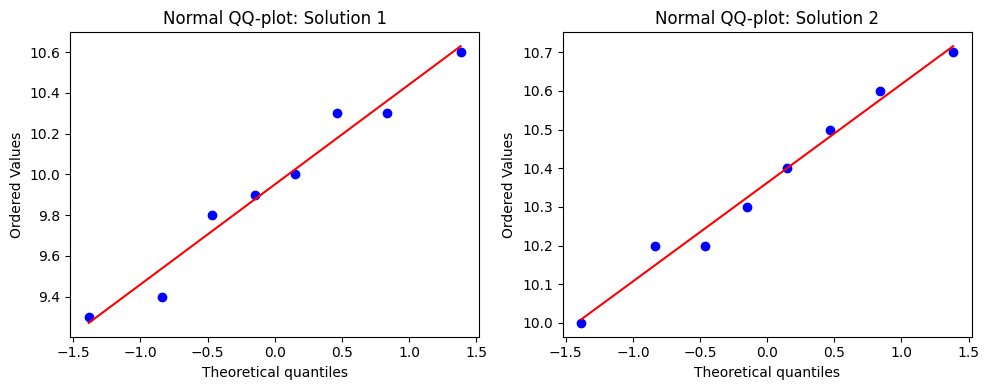

Shapiro-Wilk: Solution 1 p = 0.7603, Solution 2 p = 0.9454
F = s1^2/s2^2 = 3.749, p = 0.1024
Welch t-test: t = -2.302, p = 0.0430


In [15]:
# (c) normality and equal-variance checks
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(s1, dist="norm", plot=axes[0]); axes[0].set_title("Normal QQ-plot: Solution 1")
stats.probplot(s2, dist="norm", plot=axes[1]); axes[1].set_title("Normal QQ-plot: Solution 2")
plt.tight_layout(); plt.show()

print(f"Shapiro-Wilk: Solution 1 p = {shapiro(s1).pvalue:.4f}, Solution 2 p = {shapiro(s2).pvalue:.4f}")

# Equal variances: F-test
F = s1.var(ddof=1) / s2.var(ddof=1)
pF = 2 * min(f.cdf(F, n1 - 1, n2 - 1), 1 - f.cdf(F, n1 - 1, n2 - 1))
print(f"F = s1^2/s2^2 = {F:.3f}, p = {pF:.4f}")

# For comparison: Welch's t-test, which does not assume equal variances
w = stats.ttest_ind(s1, s2, equal_var=False)
print(f"Welch t-test: t = {w.statistic:.3f}, p = {w.pvalue:.4f}")

**(c)** Both QQ-plots are close to straight lines and Shapiro-Wilk does not reject normality ($p = 0.76$ and $0.95$).
Solution 1 has a larger spread ($s_1 = 0.45$ vs $s_2 = 0.23$, $F = 3.75$), but with 8 observations per group this is not significant ($p = 0.10$).
Welch's test, which does not need equal variances, gives the same decision ($p = 0.043$). The conclusion in (a) does not depend on this assumption.

observed effect size d = 1.151
power of the test in (a) with n = 8 per group: 0.572
Delta = 0.3 mils/min -> d = 0.837 -> n per group for power > 0.9: 31


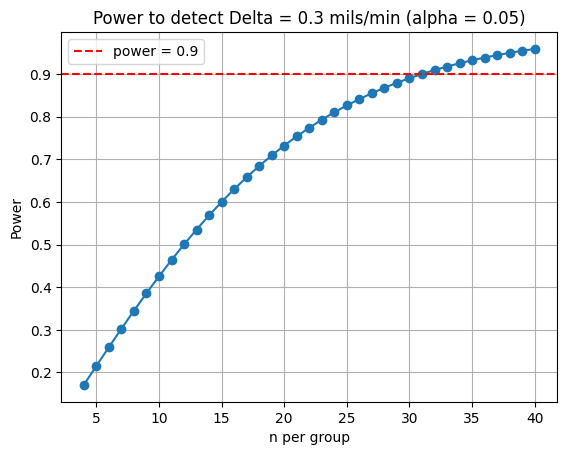

In [16]:
# (d) power of the test in (a) and sample size for Delta = 0.3
analysis = TTestIndPower()

d_obs = abs(s1.mean() - s2.mean()) / sp                  # effect size from the data
power_obs = analysis.power(effect_size=d_obs, nobs1=n1, alpha=0.05, alternative="two-sided")
print(f"observed effect size d = {d_obs:.3f}")
print(f"power of the test in (a) with n = {n1} per group: {power_obs:.3f}")

d_03 = 0.3 / sp
n_req = analysis.solve_power(effect_size=d_03, power=0.9, alpha=0.05, alternative="two-sided")
print(f"Delta = 0.3 mils/min -> d = {d_03:.3f} -> n per group for power > 0.9: {np.ceil(n_req):.0f}")

ns = np.arange(4, 41)
pw = [analysis.power(effect_size=d_03, nobs1=k, alpha=0.05, alternative="two-sided") for k in ns]
plt.plot(ns, pw, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="power = 0.9")
plt.xlabel("n per group"); plt.ylabel("Power"); plt.title("Power to detect Delta = 0.3 mils/min (alpha = 0.05)")
plt.grid(True); plt.legend(); plt.show()

**(d)** With the observed effect ($d = 0.41/0.36 \approx 1.15$) and $n = 8$ per group, the power is only **0.57**.
An experiment of this size would miss a difference of this size 43 % of the time.

To detect $\Delta = 0.3$ mils/min with power 0.9 at $\alpha = 0.05$ we need **31 wafers per group**, about four times the current sample.


### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [17]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


**Solution:**

**1) Equal variances.** $H_0:\ \sigma_1^2 = \sigma_2^2$ vs $H_1:\ \sigma_1^2 \ne \sigma_2^2$, test statistic $F_0 = s_1^2/s_2^2 \sim F(9, 9)$ under $H_0$.
We do this first, because the result decides which $t$-test to use in part 2.

In [18]:
f1 = df26["Type1"].to_numpy(dtype=float)
f2 = df26["Type2"].to_numpy(dtype=float)
n1, n2 = len(f1), len(f2)

print(f"Type 1: mean = {f1.mean():.2f}, s = {f1.std(ddof=1):.3f}, s^2 = {f1.var(ddof=1):.2f}")
print(f"Type 2: mean = {f2.mean():.2f}, s = {f2.std(ddof=1):.3f}, s^2 = {f2.var(ddof=1):.2f}")

# 1) F-test for equal variances, alpha = 0.05
F = f1.var(ddof=1) / f2.var(ddof=1)
pF = 2 * min(f.cdf(F, n1 - 1, n2 - 1), 1 - f.cdf(F, n1 - 1, n2 - 1))
print(f"\nF-test: F = {F:.4f}, df = ({n1 - 1}, {n2 - 1}), p = {pF:.4f}")
print(f"critical region: F < {f.ppf(0.025, n1 - 1, n2 - 1):.3f} or F > {f.ppf(0.975, n1 - 1, n2 - 1):.3f}")

Type 1: mean = 70.40, s = 9.264, s^2 = 85.82
Type 2: mean = 70.20, s = 9.367, s^2 = 87.73

F-test: F = 0.9782, df = (9, 9), p = 0.9744
critical region: F < 0.248 or F > 4.026


**1) Conclusion.** $F_0 = 0.978$ lies inside the acceptance region $(0.248,\ 4.026)$, $P = 0.97$. The two sample variances (85.8 and 87.7) are almost the same.
We do not reject equal variances, so we use the pooled $t$-test in part 2.

In [19]:
# 2) pooled two-sample t-test for equal means, alpha = 0.05
res = stats.ttest_ind(f1, f2, equal_var=True)
sp = np.sqrt(((n1 - 1) * f1.var(ddof=1) + (n2 - 1) * f2.var(ddof=1)) / (n1 + n2 - 2))
se = sp * np.sqrt(1 / n1 + 1 / n2)
ci = stats.t.interval(0.95, df=n1 + n2 - 2, loc=f1.mean() - f2.mean(), scale=se)

print(f"difference of means = {f1.mean() - f2.mean():.2f} min, sp = {sp:.3f}, se = {se:.3f}")
print(f"t = {res.statistic:.4f}, df = {n1 + n2 - 2}, p = {res.pvalue:.4f}, critical value = ±{stats.t.ppf(0.975, n1 + n2 - 2):.3f}")
print(f"95% CI for mu1 - mu2: ({ci[0]:.2f}, {ci[1]:.2f}) min")

difference of means = 0.20 min, sp = 9.315, se = 4.166
t = 0.0480, df = 18, p = 0.9622, critical value = ±2.101
95% CI for mu1 - mu2: (-8.55, 8.95) min


**2) Conclusion.** $t_0 = 0.048$, $P = 0.96$. The means differ by 0.2 min (70.4 vs 70.2), the standard error is 4.2 min.
We do not reject $H_0$: there is no evidence that the two types differ in mean burning time.
The 95 % CI $(-8.6,\ 9.0)$ min is wide: a difference of several minutes in either direction is still possible.

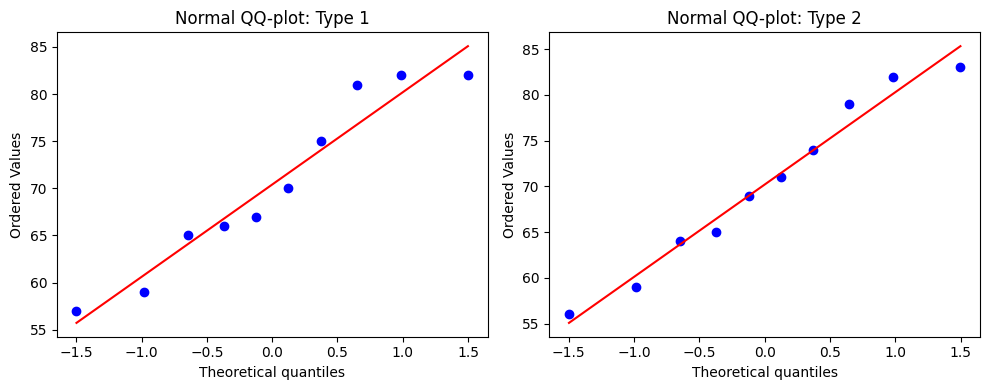

Shapiro-Wilk Type 1: W = 0.9136, p = 0.3065
Shapiro-Wilk Type 2: W = 0.9548, p = 0.7251


In [20]:
# 3) normality of both types
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(f1, dist="norm", plot=axes[0]); axes[0].set_title("Normal QQ-plot: Type 1")
stats.probplot(f2, dist="norm", plot=axes[1]); axes[1].set_title("Normal QQ-plot: Type 2")
plt.tight_layout(); plt.show()

for name, x in [("Type 1", f1), ("Type 2", f2)]:
    sw = shapiro(x)
    print(f"Shapiro-Wilk {name}: W = {sw.statistic:.4f}, p = {sw.pvalue:.4f}")

**3) Role of normality.** The $F$-test for variances is very sensitive to non-normality, and this does not improve with larger $n$.
The $t$-test for means is much more robust, because the sample mean is close to normal by the central limit theorem.

The QQ-plots are close to straight lines and Shapiro-Wilk does not reject ($p = 0.31$ and $0.73$), so normality is a reasonable assumption for both types.

In [21]:
# 4) power for a true difference of 2 min, and sample size for 1 min with power 0.9
analysis = TTestIndPower()

d_2 = 2 / sp
power_2 = analysis.power(effect_size=d_2, nobs1=n1, alpha=0.05, alternative="two-sided")
print(f"Delta = 2 min -> d = {d_2:.3f} -> power with n = {n1} per group: {power_2:.3f}")

d_1 = 1 / sp
n_1 = analysis.solve_power(effect_size=d_1, power=0.9, alpha=0.05, alternative="two-sided")
print(f"Delta = 1 min -> d = {d_1:.4f} -> n per group for power 0.9: {np.ceil(n_1):.0f}")

Delta = 2 min -> d = 0.215 -> power with n = 10 per group: 0.074
Delta = 1 min -> d = 0.1073 -> n per group for power 0.9: 1825


**4) Power.** With $s_p \approx 9.3$ min, a 2-minute difference is $d \approx 0.21$. The power with 10 flares per type is only **0.07**.
The experiment cannot see a difference of this size, so the result in part 2 says almost nothing about it.

To detect a 1-minute difference with power 0.9 we would need about **1 825 flares per type**. Sample size grows with $1/\Delta^2$: half the difference needs four times the flares.
If 1-2 minutes matter, this experiment was far too small.

### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [22]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


**Solution:**

**Hypotheses.** A higher score means fewer defects. The claim is that the longer cool-down (20 s) gives a higher mean score:

$$H_0:\ \mu_{20} = \mu_{10} \qquad H_1:\ \mu_{20} > \mu_{10} \quad\text{(one-sided)},\qquad n_{10} = n_{20} = 20,\ df = 38.$$

In [23]:
c10 = df30["10 seconds"].to_numpy(dtype=float)
c20 = df30["20 seconds"].to_numpy(dtype=float)
n1, n2 = len(c10), len(c20)

print(f"10 s: mean = {c10.mean():.2f}, s = {c10.std(ddof=1):.3f}")
print(f"20 s: mean = {c20.mean():.2f}, s = {c20.std(ddof=1):.3f}")
F = c10.var(ddof=1) / c20.var(ddof=1)
pF = 2 * min(f.cdf(F, n1 - 1, n2 - 1), 1 - f.cdf(F, n1 - 1, n2 - 1))
print(f"F-test for equal variances: F = {F:.3f}, p = {pF:.4f}")

# one-sided pooled t-test, H1: mu20 > mu10
res = stats.ttest_ind(c20, c10, equal_var=True, alternative="greater")
sp = np.sqrt(((n1 - 1) * c10.var(ddof=1) + (n2 - 1) * c20.var(ddof=1)) / (n1 + n2 - 2))
se = sp * np.sqrt(1 / n1 + 1 / n2)
t_crit = stats.t.ppf(0.95, df=n1 + n2 - 2)

print(f"\ndifference (20 s - 10 s) = {c20.mean() - c10.mean():.2f} points, sp = {sp:.3f}, se = {se:.3f}")
print(f"t = {res.statistic:.3f}, df = {n1 + n2 - 2}, one-sided p = {res.pvalue:.2e}, critical value t_0.95(38) = {t_crit:.3f}")

# 95% two-sided CI on mu20 - mu10
ci = stats.t.interval(0.95, df=n1 + n2 - 2, loc=c20.mean() - c10.mean(), scale=se)
print(f"95% CI for mu20 - mu10: ({ci[0]:.2f}, {ci[1]:.2f}) points")

10 s: mean = 3.35, s = 2.007
20 s: mean = 6.50, s = 1.539
F-test for equal variances: F = 1.701, p = 0.2559

difference (20 s - 10 s) = 3.15 points, sp = 1.788, se = 0.566
t = 5.570, df = 38, one-sided p = 1.11e-06, critical value t_0.95(38) = 1.686
95% CI for mu20 - mu10: (2.01, 4.29) points


**Test and $P$-value.** $t_0 = 5.57 > t_{0.95}(38) = 1.69$, one-sided $P \approx 1.1 \times 10^{-6}$. We **reject $H_0$**: the longer cool-down time gives fewer defects.
If the two times were equal, a difference this large would appear in about one experiment in a million.

**Confidence interval.** The 95 % CI for $\mu_{20} - \mu_{10}$ is $(2.0,\ 4.3)$ points. Even the lower end is a 2-point improvement.
The average score moves from about 3.4 to about 6.5. This is a difference a customer would see. The interval, unlike the $P$-value, tells us *how much* the extra 10 seconds help.

In [24]:
# Power of the one-sided test
analysis = TTestIndPower()

d_obs = (c20.mean() - c10.mean()) / sp
power_obs = analysis.power(effect_size=d_obs, nobs1=n1, alpha=0.05, alternative="larger")
n_min = analysis.solve_power(effect_size=d_obs, power=0.9, alpha=0.05, alternative="larger")
power_1pt = analysis.power(effect_size=1 / sp, nobs1=n1, alpha=0.05, alternative="larger")

print(f"observed effect size d = {d_obs:.3f}")
print(f"power with n = {n1} per group: {power_obs:.4f}")
print(f"n per group that would already give power 0.9 for this effect: {np.ceil(n_min):.0f}")
print(f"for comparison, power to detect a 1-point difference with n = 20: {power_1pt:.3f}")

observed effect size d = 1.761
power with n = 20 per group: 0.9999
n per group that would already give power 0.9 for this effect: 7
for comparison, power to detect a 1-point difference with n = 20: 0.537


**Power.** The effect is large, $d \approx 1.76$, and with 20 housings per group the power is **0.9999**. Already 7 housings per group would give power 0.9.
The 40 observations are still useful: they make the confidence interval narrow. A smaller effect, for example a 1-point difference, would be detected with power of only 0.54.